In [ ]:
import sys
from pathlib import Path
for _root in [Path.cwd(), *Path.cwd().parents]:
    _p = _root / "paths.py"
    if _p.exists() and "SHARED_ROOT" in _p.read_text(encoding="utf-8", errors="ignore"):
        sys.path.insert(0, str(_root))
        break
else:
    raise RuntimeError(
        "Could not find After_PT_Removal/shared/paths.py — set Jupyter cwd to After_PT_Removal, shared/, or shared/notebooks/."
    )
import paths


In [2]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


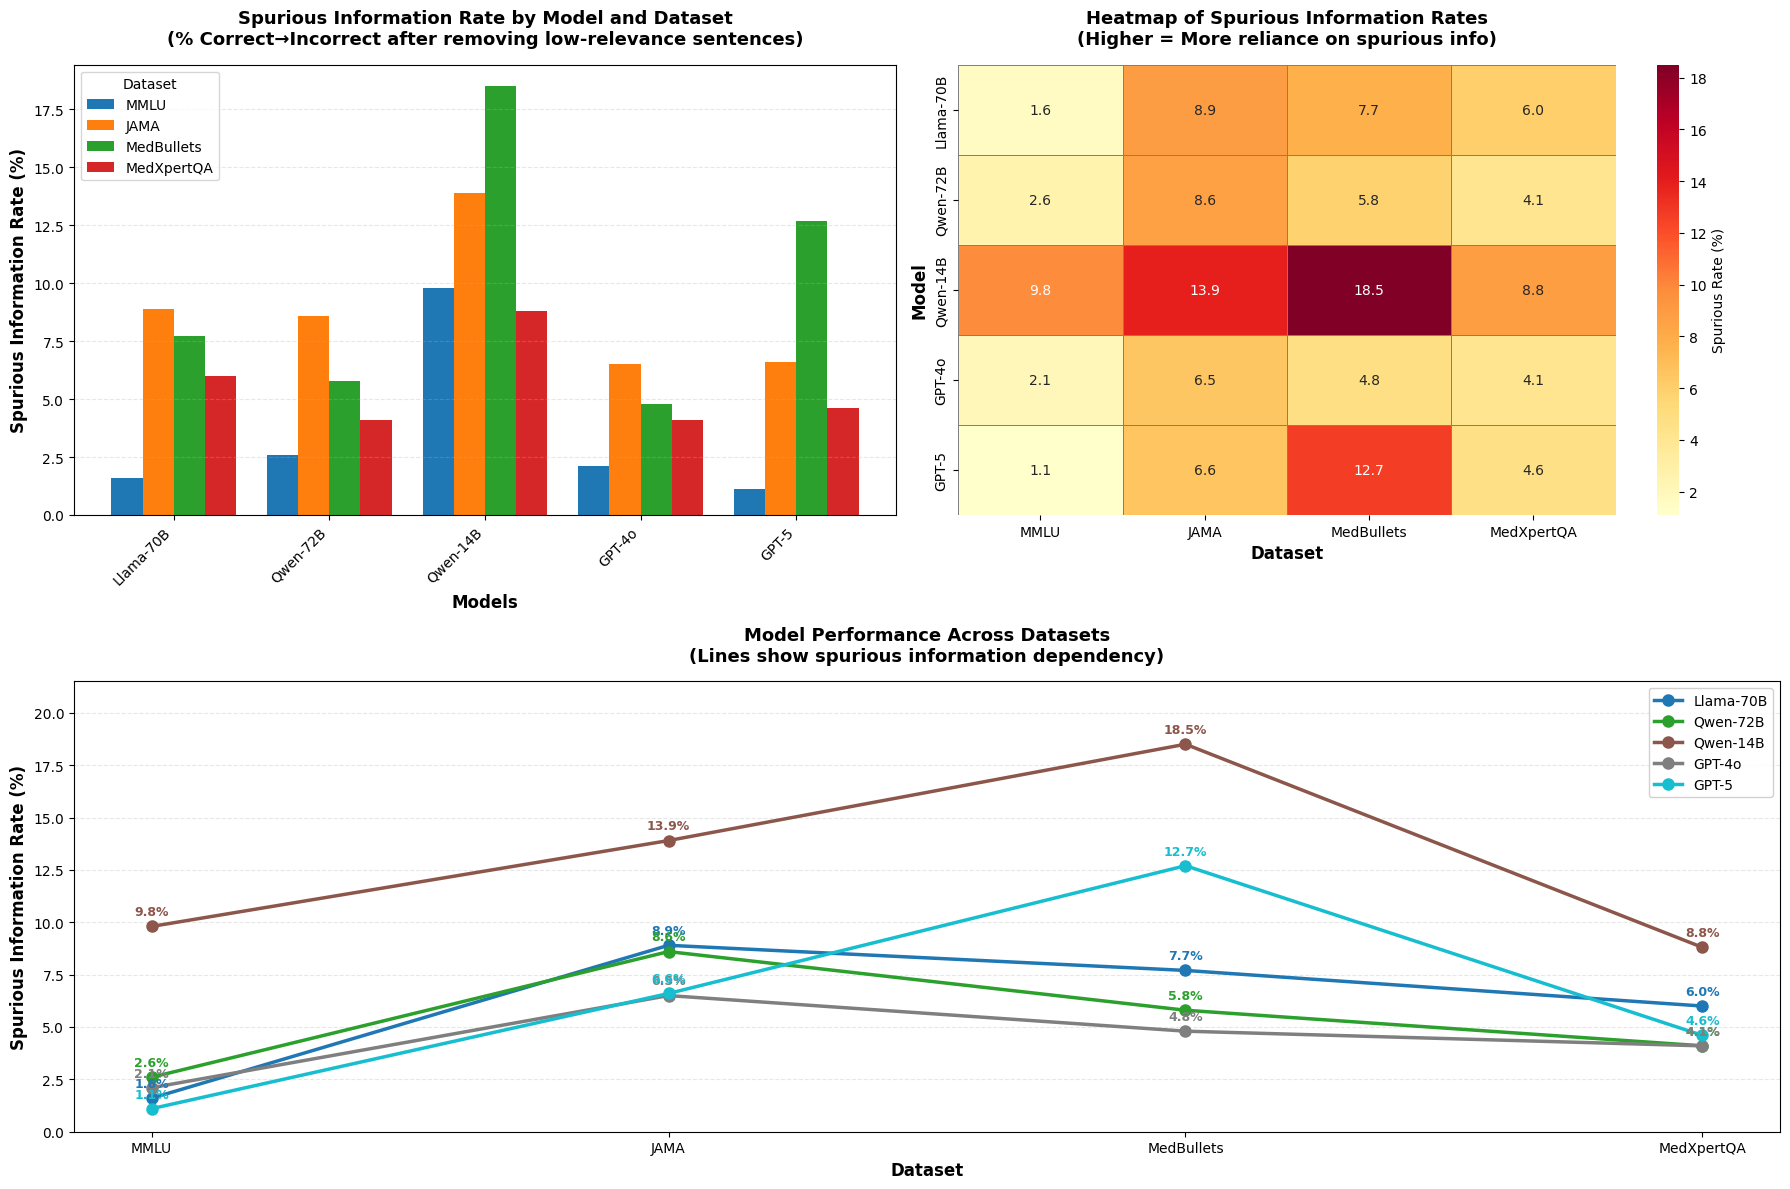

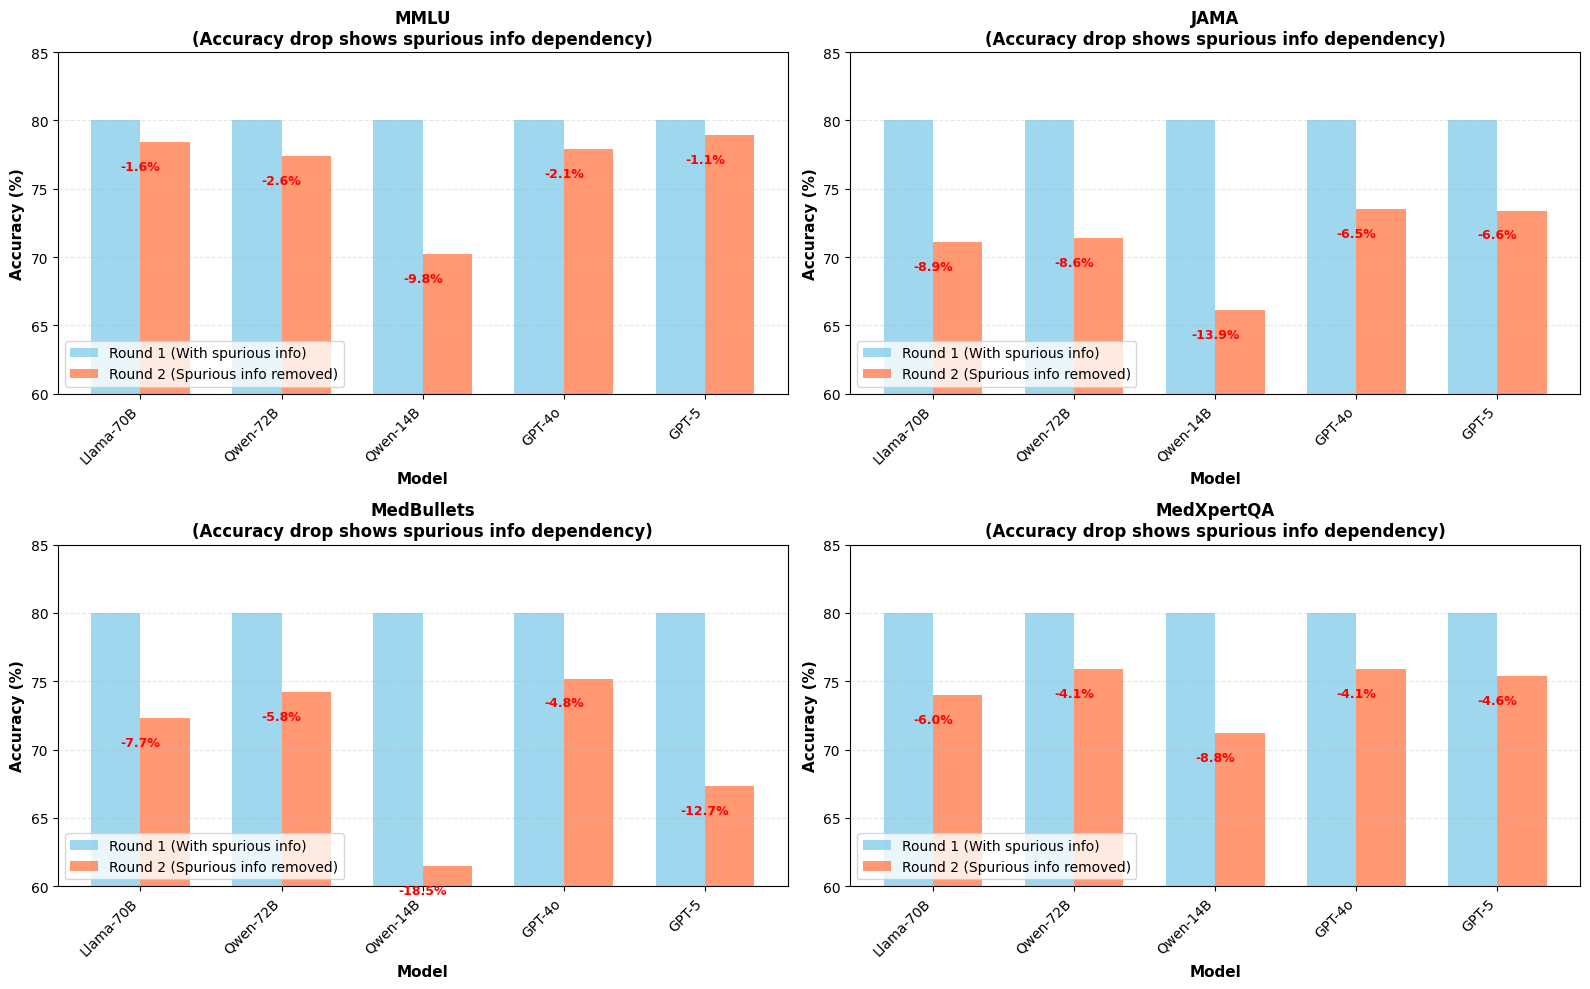

Visualizations saved successfully!

Key insights:
- Higher spurious rate = Model relies more on irrelevant information
- Qwen-14B shows highest dependency on spurious information
- GPT-5 shows lowest dependency on MMLU but higher on MedBullets


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Data
models = ['Llama-70B', 'Qwen-72B', 'Qwen-14B', 'GPT-4o', 'GPT-5']
datasets = ['MMLU', 'JAMA', 'MedBullets', 'MedXpertQA']

spurious_rates = {
    'Llama-70B': [1.6, 8.9, 7.7, 6.0],
    'Qwen-72B': [2.6, 8.6, 5.8, 4.1],
    'Qwen-14B': [9.8, 13.9, 18.5, 8.8],
    'GPT-4o': [2.1, 6.5, 4.8, 4.1],
    'GPT-5': [1.1, 6.6, 12.7, 4.6]
}

# Create a figure with all three visualizations
fig = plt.figure(figsize=(18, 12))

# ========== Visualization 1: Grouped Bar Chart ==========
ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(models))
width = 0.2

for i, dataset in enumerate(datasets):
    values = [spurious_rates[model][i] for model in models]
    ax1.bar(x + i * width, values, width, label=dataset)

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Spurious Information Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Spurious Information Rate by Model and Dataset\n(% Correct→Incorrect after removing low-relevance sentences)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend(title='Dataset', loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ========== Visualization 2: Heatmap ==========
ax2 = plt.subplot(2, 2, 2)
data_matrix = np.array([spurious_rates[model] for model in models])

sns.heatmap(data_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=datasets, yticklabels=models, 
            cbar_kws={'label': 'Spurious Rate (%)'}, ax=ax2,
            linewidths=0.5, linecolor='gray')
ax2.set_title('Heatmap of Spurious Information Rates\n(Higher = More reliance on spurious info)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax2.set_ylabel('Model', fontsize=12, fontweight='bold')

# ========== Visualization 3: Slope Chart ==========
ax3 = plt.subplot(2, 1, 2)

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
x_pos = np.arange(len(datasets))

for idx, model in enumerate(models):
    values = spurious_rates[model]
    ax3.plot(x_pos, values, marker='o', linewidth=2.5, 
             label=model, color=colors[idx], markersize=8)
    
    # Add value labels
    for i, v in enumerate(values):
        ax3.annotate(f'{v:.1f}%', (x_pos[i], v), 
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=9, color=colors[idx],
                    fontweight='bold')

ax3.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax3.set_ylabel('Spurious Information Rate (%)', fontsize=12, fontweight='bold')
ax3.set_title('Model Performance Across Datasets\n(Lines show spurious information dependency)', 
              fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(datasets)
ax3.legend(loc='upper right', framealpha=0.9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim(0, max([max(v) for v in spurious_rates.values()]) + 3)

plt.tight_layout()
plt.savefig('spurious_information_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== Alternative: Before/After Comparison ==========
# This shows the conceptual Round 1 vs Round 2 accuracy

fig2, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    # Assume baseline accuracy of 80% for demonstration
    # Round 2 accuracy = Round 1 accuracy - spurious rate
    baseline = 80
    
    round1_acc = [baseline] * len(models)
    round2_acc = [baseline - spurious_rates[model][idx] for model in models]
    
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, round1_acc, width, label='Round 1 (With spurious info)', 
                   color='skyblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, round2_acc, width, label='Round 2 (Spurious info removed)', 
                   color='coral', alpha=0.8)
    
    # Add difference annotations
    for i in range(len(models)):
        diff = round1_acc[i] - round2_acc[i]
        ax.annotate(f'-{diff:.1f}%', xy=(i, round2_acc[i]), 
                   xytext=(0, -20), textcoords='offset points',
                   ha='center', fontsize=9, color='red', fontweight='bold')
    
    ax.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset}\n(Accuracy drop shows spurious info dependency)', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend(loc='lower left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(60, 85)

plt.tight_layout()
plt.savefig('round1_vs_round2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved successfully!")
print("\nKey insights:")
print("- Higher spurious rate = Model relies more on irrelevant information")
print("- Qwen-14B shows highest dependency on spurious information")
print("- GPT-5 shows lowest dependency on MMLU but higher on MedBullets")